# Q1: Regression Problem - Ceramic Strength

<b>Context:</b> Your colleagues have been tasked to develop an industrial process to synthesize porcelain materials for consumer goods. Whereas traditional porcelains rely on locally-sourced mineral deposits such as kaolinite and feldspars, the industrial process requires the use of high-purity chemical precursors in the form of powders for consistency and scalability. The materials the experimental team have at their disposal are alumina (Al2O3), silica (SiO2), and calcia (CaO). After an extensive research period of synthesis and characterization, they have given you the results of their labour in the form of a database, `ceramic_data.csv`.

#### a)
We use the property fracture_toughness as the response variable. The predictors are alumina_content, silica_content, calcia_content, sintering_temperature, holding_time, heating_rate, and cooling_rate. Plot the distribution of each predictor, and comment on what the distributions indicate about the experimental process.

In [14]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.metrics import mean_squared_error

In [2]:
cData = pd.read_csv('ceramic_data.csv')
cData.head()

,sample_id,sample_type,alumina_content,silica_content,calcia_content,sintering_temperature,holding_time,heating_rate,cooling_rate,alpha_alumina_phase,...,glass_phase,grain_size,grain_uniformity,total_porosity,closed_porosity,open_porosity,pore_size,fracture_toughness,flexural_strength,youngs_modulus
0,CER-001,composition_series,85.00,11.75,3.25,1600.0,4.0,10.0,5.0,81.3,...,11.0,1.50,0.500,11.83,5.92,5.92,0.1,2.55,525.5,309.1
1,CER-002,composition_series,85.02,10.37,4.60,1600.0,4.0,10.0,5.0,81.0,...,10.0,1.28,0.435,11.56,5.78,5.78,0.1,2.57,574.7,316.8
2,CER-003,composition_series,85.05,11.30,3.65,1600.0,4.0,10.0,5.0,81.3,...,10.0,1.32,0.489,10.94,5.47,5.47,0.1,3.08,552.2,310.6
3,CER-004,composition_series,85.07,10.63,4.29,1600.0,4.0,10.0,5.0,82.2,...,10.1,1.24,0.426,11.65,5.82,5.82,0.1,3.09,544.8,318.3
4,CER-005,composition_series,85.10,8.56,6.34,1600.0,4.0,10.0,5.0,82.7,...,8.8,1.06,0.500,10.67,5.34,5.34,0.1,2.71,570.8,324.5


In [3]:
print("Data type : ", type(cData))
print("Data dims : ", cData.shape)

Data type :  <class 'pandas.core.frame.DataFrame'>
Data dims :  (1527, 22)


In [4]:
cData.columns

Index(['sample_id', 'sample_type', 'alumina_content', 'silica_content',
       'calcia_content', 'sintering_temperature', 'holding_time',
       'heating_rate', 'cooling_rate', 'alpha_alumina_phase',
       'calcium_aluminate_phase', 'mullite_phase', 'glass_phase', 'grain_size',
       'grain_uniformity', 'total_porosity', 'closed_porosity',
       'open_porosity', 'pore_size', 'fracture_toughness', 'flexural_strength',
       'youngs_modulus'],
      dtype='object')

In [5]:
print(cData.dtypes)

sample_id                   object
sample_type                 object
alumina_content            float64
silica_content             float64
calcia_content             float64
sintering_temperature      float64
holding_time               float64
heating_rate               float64
cooling_rate               float64
alpha_alumina_phase        float64
calcium_aluminate_phase    float64
mullite_phase              float64
glass_phase                float64
grain_size                 float64
grain_uniformity           float64
total_porosity             float64
closed_porosity            float64
open_porosity              float64
pore_size                  float64
fracture_toughness         float64
flexural_strength          float64
youngs_modulus             float64
dtype: object


In [6]:
# Extract Response and Predictors - why dataframes are good to work with
y = pd.DataFrame(cData["fracture_toughness"])
X = pd.DataFrame(cData[["alumina_content", "silica_content", "calcia_content", 'sintering_temperature', 'holding_time', 'heating_rate', 'cooling_rate']])

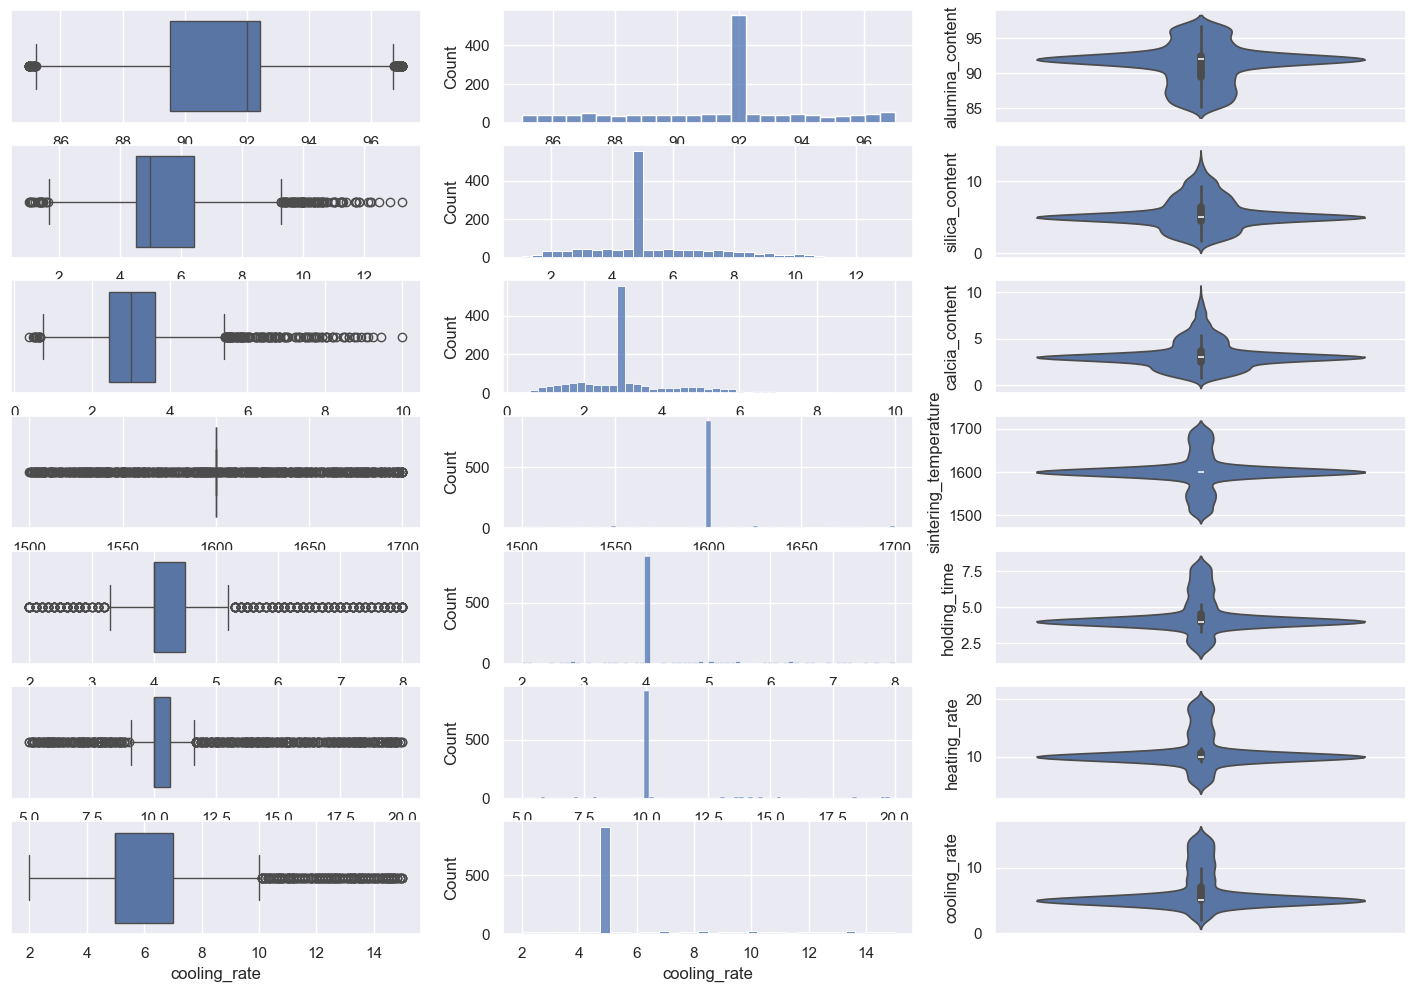

In [7]:
# Draw the distributions of all Predictors
f, axes = plt.subplots(7, 3, figsize=(18, 12))

count = 0
for var in X:
    sb.boxplot(data=X[var], orient = "h", ax = axes[count,0])
    sb.histplot(data=X[var], ax = axes[count,1])
    sb.violinplot(data=X[var], ax = axes[count,2])
    count += 1

#### b)

Partition the dataset randomly into train and test datasets, assigning 26% to the test set. Fit a linear regression model onto the train set. Plot the predicted and actual values of the train and test sets onto the same y-y plot. Quote the goodness of fit using R2 and Mean Square Error values.

In [22]:
# Import essential models and functions from sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Extract Response and Predictors - why dataframes are good to work with
y = pd.DataFrame(cData["fracture_toughness"])
X = pd.DataFrame(cData[["alumina_content", "silica_content", "calcia_content", 'sintering_temperature', 'holding_time', 'heating_rate', 'cooling_rate']])

# Split the Dataset into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.26)

X_train.describe()
#X_test.describe()

,alumina_content,silica_content,calcia_content,sintering_temperature,holding_time,heating_rate,cooling_rate
count,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000
mean,91.271825,5.439672,3.288423,1600.560053,4.390788,10.967582,6.433304
std,2.898969,2.114277,1.536819,38.843040,1.192323,3.033143,2.966352
min,85.000000,1.040000,0.390000,1500.000000,2.000000,5.000000,2.000000
25%,89.350000,4.520000,2.500000,1600.000000,4.000000,10.000000,5.000000
50%,92.000000,5.000000,3.000000,1600.000000,4.000000,10.000000,5.000000
75%,92.410000,6.450000,3.720000,1600.000000,4.500000,10.600000,7.000000
max,97.000000,12.860000,9.450000,1700.000000,8.000000,20.000000,15.000000


In [23]:
# Linear Regression using Train Data
linreg_new = LinearRegression()         # create the linear regression object
linreg_new.fit(X_train, y_train)        # train the linear regression model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
# Determine the Coefficients of the Linear Regression line
print('Intercept of Regression \t: b = ', linreg_new.intercept_)
print('Coefficients of Regression \t: a = ', linreg_new.coef_)
print()

Intercept of Regression 	: b =  [-171.67867807]
Coefficients of Regression 	: a =  [[ 1.75135450e+00  1.76907942e+00  1.78806210e+00 -7.27818285e-04
   6.78599431e-02 -2.65173530e-03 -6.78143467e-03]]



In [25]:
# Predict Total values corresponding to HP
y_train_pred = linreg_new.predict(X_train)
y_test_pred = linreg_new.predict(X_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Explained Variance (R^2) \t:", linreg_new.score(X_train, y_train))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_train, y_train_pred))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Explained Variance (R^2) \t:", linreg_new.score(X_test, y_test))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_test, y_test_pred))
print()

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(r2_train, r2_test)

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.2249642850679766
Mean Squared Error (MSE) 	: 0.04294129959942295

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.15007738507653678
Mean Squared Error (MSE) 	: 0.050837687354278176

0.2249642850679766 0.15007738507653678


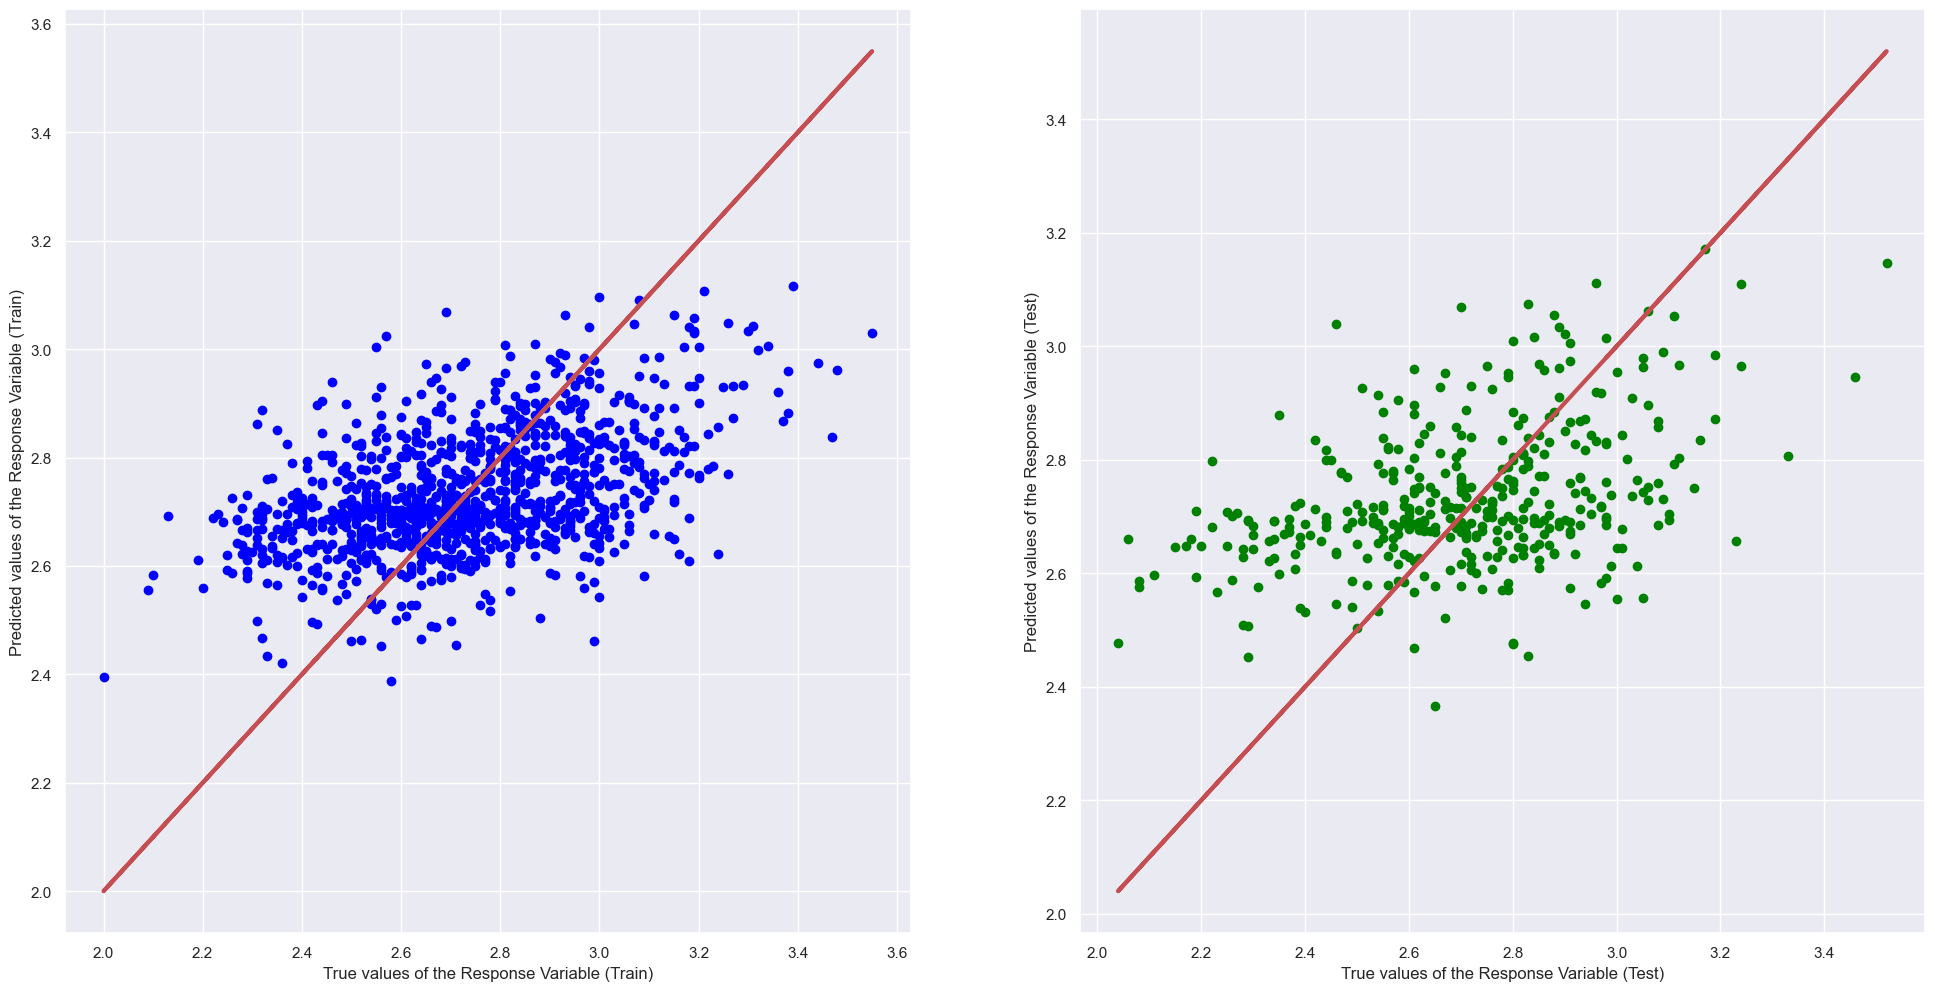

In [26]:
# Plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, y_train_pred, color = "blue")
axes[0].plot(y_train, y_train, 'r-', linewidth = 3)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, y_test_pred, color = "green")
axes[1].plot(y_test, y_test, 'r-', linewidth = 3)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")
plt.show()

#### c)

Correlate the predictors and response variables with a correlation heatmap. Which predictor has the most influence on fracture toughness? Why are negative numbers present on the correlation heatmap?

<Axes: >

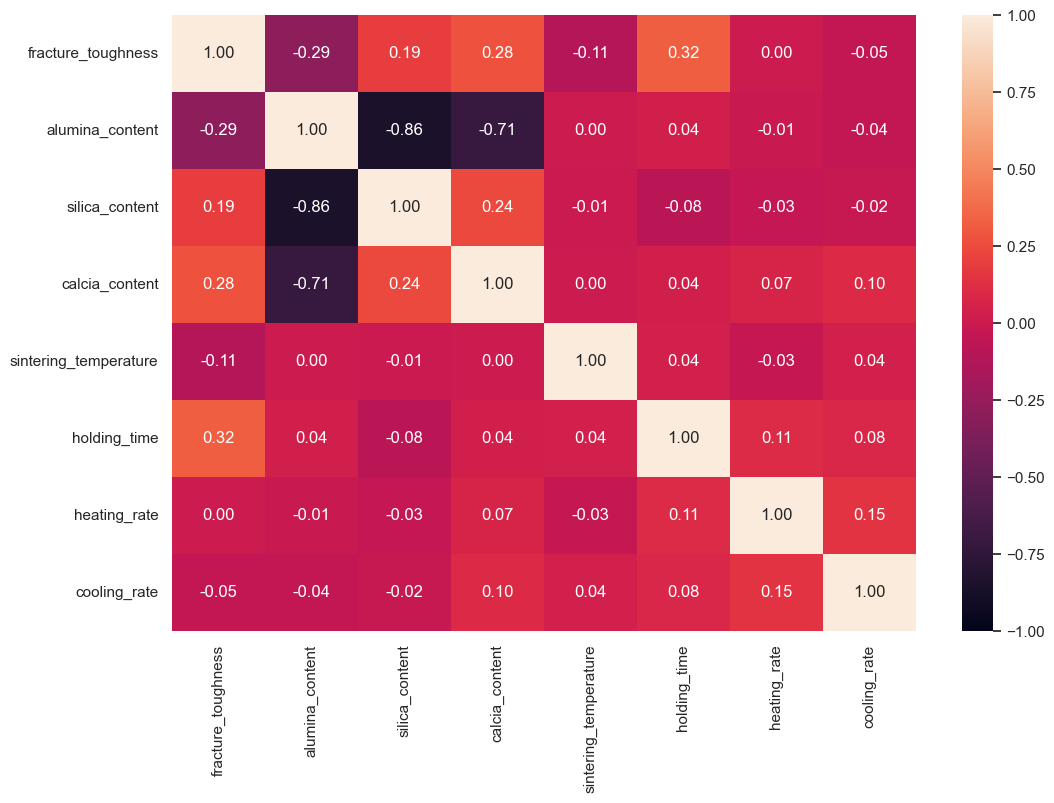

In [27]:
# Correlation between Response and the Predictors
trainDF = pd.concat([y_train, X_train], axis = 1)

f, axes = plt.subplots(1, 1, figsize=(12, 8))
sb.heatmap(trainDF.corr(), vmin = -1, vmax = 1, annot = True, fmt = ".2f")

# Problem 2: Classification

<b>Context:</b> To supplement your family’s lobster cannery business, you have developed and characterized a new polymer material from chitin, so as to make the best use of discarded lobster shells at the cannery. Potential investors of your product are interested in possible industrial applications for your new material. However, it is only 1 hour from your presentation, and you do not even know if the new material is a thermoplastic or a thermosetting plastic. Fortunately, after 40 minutes, you were able to hack into DuPont’s secret files, which contains a database of all plastics made under their brands. This database is `polymer_data.csv`. You have 20 minutes to train a classification model upon this database, and to categorise your new material. 

#### a)	
Plot the distribution of polymer_type to check the proportion of thermoplastics and thermosetting plastics in the dataset. What is the ratio of thermoplastics against thermosetting plastics in the database?

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics

In [2]:
pData = pd.read_csv('polymer_data.csv')
pData.head()

,Unnamed: 0,molecular_weight,polydispersity,crystallinity,crosslink_density,processing_temp,cooling_rate,pressure,glass_transition_temp,heat_deflection_temp,youngs_modulus,tensile_strength,elongation_at_break,polymer_type
0,0,86758,2.25,69.9,0.001,266.8,25.6,185.0,49.6,39.9,6279,56.4,173.1,Thermoplastic
1,1,186854,3.29,58.3,0.039,227.3,23.1,185.8,57.5,42.8,5590,51.7,233.2,Thermoplastic
2,2,117620,3.16,75.5,0.001,210.0,51.7,333.9,53.6,41.1,6974,55.9,174.4,Thermoplastic
3,3,54806,2.92,32.4,0.038,218.3,56.4,115.5,45.8,32.7,3247,32.8,221.6,Thermoplastic
4,4,25353,2.07,1.6,0.836,126.9,3.2,74.4,166.8,177.5,6883,101.5,18.3,Thermosetting


In [11]:
pData['polymer_type'].value_counts()

polymer_type
Thermoplastic    346
Thermosetting    154
Name: count, dtype: int64

In [13]:
count1, count2 = pData['polymer_type'].value_counts()
count2/count1

0.44508670520231214

In [16]:
print("Data type : ", type(pData))
print("Data dims : ", pData.shape)

Data type :  <class 'pandas.core.frame.DataFrame'>
Data dims :  (500, 14)


In [3]:
pData['polymer_type'].describe()

count               500
unique                2
top       Thermoplastic
freq                346
Name: polymer_type, dtype: object

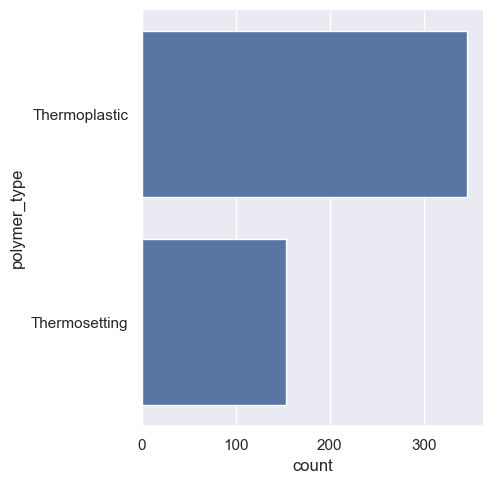

In [18]:
sb.catplot(y = 'polymer_type', data = pData, kind = "count")

#### b)	
Import the Classification Tree model from Scikit-Learn : from sklearn.tree import DecisionTreeClassifier. Partition the dataset randomly into Train (70%) and Test (30%) sets. Train the classification tree model using molecular weight as the predictor. Print accuracy measures of the Decision Tree model, including its Classification Accuracy, True Positive Rate, True Negative Rate, False Positive Rate and False Negative Rate, based on the confusion matrix on train data.

In [20]:
# Import Decision Tree Classifier model from Scikit-Learn
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree Classifier object
# you can change the max_depth as you wish
dectree = DecisionTreeClassifier(max_depth = 3)

In [21]:
# Import the required function from sklearn
from sklearn.model_selection import train_test_split

# Extract Response and Predictors
y = pd.DataFrame(pData['polymer_type'])
X = pd.DataFrame(pData['molecular_weight'])

# Split the Dataset into random Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

# Check the sample sizes
print("Train Set :", X_train.shape, y_train.shape)
print("Test Set  :", X_test.shape, y_test.shape)

Train Set : (350, 1) (350, 1)
Test Set  : (150, 1) (150, 1)


In [22]:
dectree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

[Text(0.5, 0.875, 'molecular_weight <= 50767.0\ngini = 0.42\nsamples = 350\nvalue = [245.0, 105.0]\nclass = Thermoplastic'),
 Text(0.25, 0.625, 'molecular_weight <= 31171.0\ngini = 0.47\nsamples = 138\nvalue = [52, 86]\nclass = Thermosetting'),
 Text(0.125, 0.375, 'molecular_weight <= 18835.5\ngini = 0.26\nsamples = 52\nvalue = [8, 44]\nclass = Thermosetting'),
 Text(0.0625, 0.125, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]\nclass = Thermosetting'),
 Text(0.1875, 0.125, 'gini = 0.292\nsamples = 45\nvalue = [8, 37]\nclass = Thermosetting'),
 Text(0.375, 0.375, 'molecular_weight <= 50016.0\ngini = 0.5\nsamples = 86\nvalue = [44, 42]\nclass = Thermoplastic'),
 Text(0.3125, 0.125, 'gini = 0.499\nsamples = 84\nvalue = [44, 40]\nclass = Thermoplastic'),
 Text(0.4375, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = Thermosetting'),
 Text(0.75, 0.625, 'molecular_weight <= 60127.5\ngini = 0.163\nsamples = 212\nvalue = [193, 19]\nclass = Thermoplastic'),
 Text(0.625, 0.375, 'molecular_wei

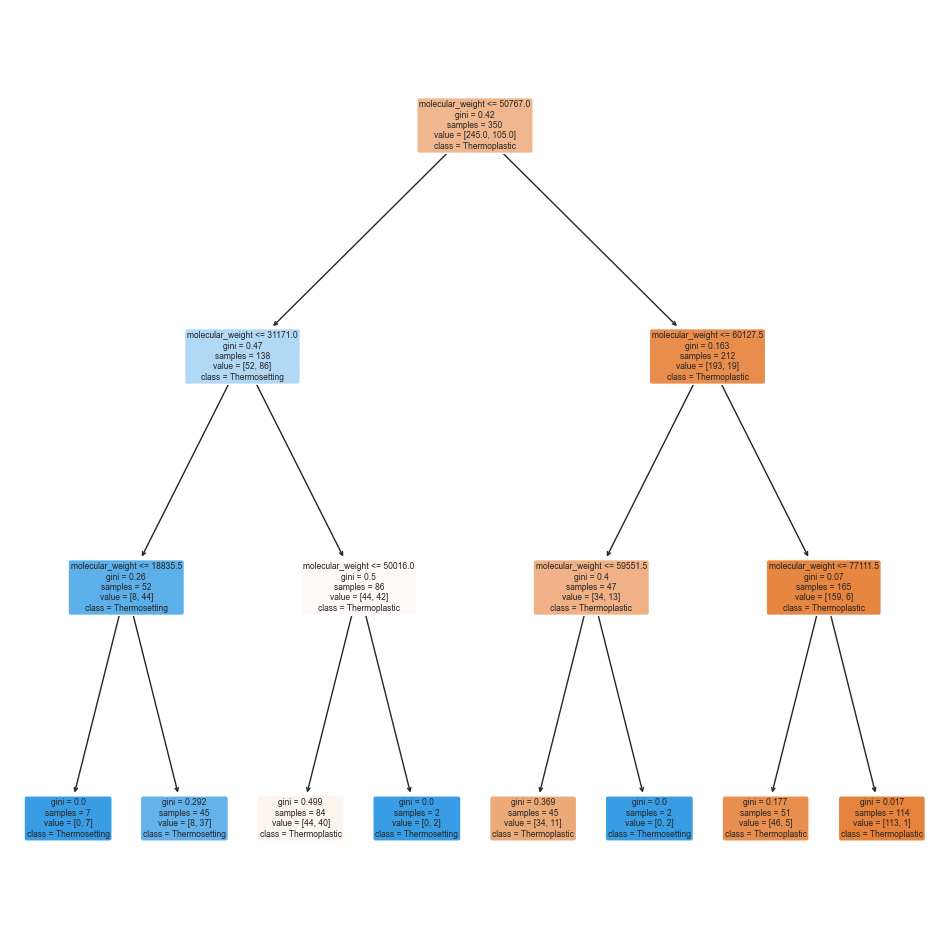

In [23]:
# Plot the trained Decision Tree
from sklearn.tree import plot_tree

f = plt.figure(figsize=(12,12))
plot_tree(dectree, filled=True, rounded=True, 
          feature_names=X_train.columns, 
          class_names=["Thermoplastic","Thermosetting"])

<Axes: >

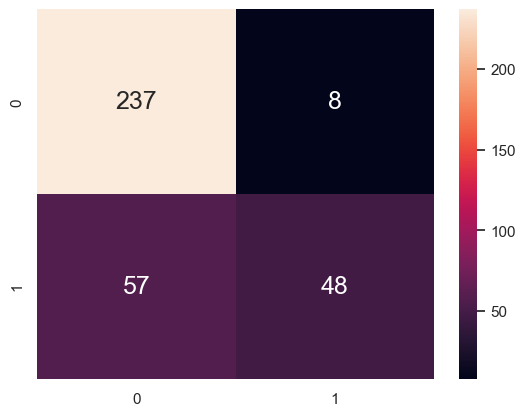

In [24]:
# Import the required metric from sklearn
from sklearn.metrics import confusion_matrix

# Predict the Response corresponding to Predictors
y_train_pred = dectree.predict(X_train)

# Plot the two-way Confusion Matrix
sb.heatmap(confusion_matrix(y_train, y_train_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18})

#### c)	
From your own characterization experiments, you are aware that your new material has a molecular weight of 19500 Da and polydispersity of 0.26. What is the category of your material? Train a new classification tree using molecular weight and polydispersity as predictors. Again, evaluate the tree based on Classification Accuracy, True Positive Rate, True Negative Rate, False Positive Rate and False Negative Rate.

In [29]:
# ANSWER: Thermosetting

In [25]:
# Extract Response and Predictors
predictors = ['molecular_weight', 'polydispersity']
y = pd.DataFrame(pData['polymer_type'])
X = pd.DataFrame(pData[predictors]) 

# Split the Dataset into random Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

# Check the sample sizes
print("Train Set :", X_train.shape, y_train.shape)
print("Test Set  :", X_test.shape, y_test.shape)

Train Set : (350, 2) (350, 1)
Test Set  : (150, 2) (150, 1)


In [26]:
dectree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

[Text(0.625, 0.875, 'polydispersity <= 2.185\ngini = 0.437\nsamples = 350\nvalue = [237, 113]\nclass = Thermoplastic'),
 Text(0.5, 0.625, 'molecular_weight <= 56251.5\ngini = 0.435\nsamples = 166\nvalue = [53.0, 113.0]\nclass = Thermosetting'),
 Text(0.25, 0.375, 'polydispersity <= 1.815\ngini = 0.248\nsamples = 117\nvalue = [17, 100]\nclass = Thermosetting'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 52\nvalue = [0, 52]\nclass = Thermosetting'),
 Text(0.375, 0.125, 'gini = 0.386\nsamples = 65\nvalue = [17, 48]\nclass = Thermosetting'),
 Text(0.75, 0.375, 'polydispersity <= 1.795\ngini = 0.39\nsamples = 49\nvalue = [36, 13]\nclass = Thermoplastic'),
 Text(0.625, 0.125, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]\nclass = Thermosetting'),
 Text(0.875, 0.125, 'gini = 0.142\nsamples = 39\nvalue = [36, 3]\nclass = Thermoplastic'),
 Text(0.75, 0.625, 'gini = 0.0\nsamples = 184\nvalue = [184, 0]\nclass = Thermoplastic')]

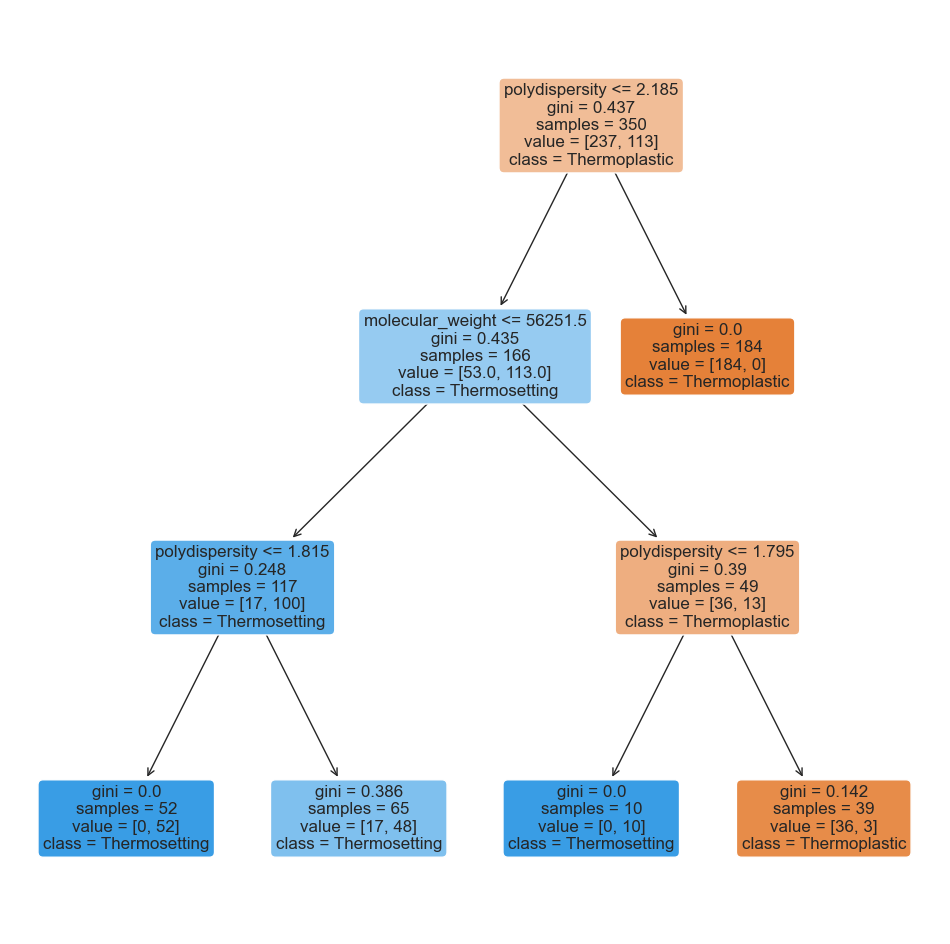

In [27]:
# Plot the trained Decision Tree
from sklearn.tree import plot_tree

f = plt.figure(figsize=(12,12))
plot_tree(dectree, filled=True, rounded=True, 
          feature_names=X_train.columns, 
          class_names=["Thermoplastic","Thermosetting"])

<Axes: >

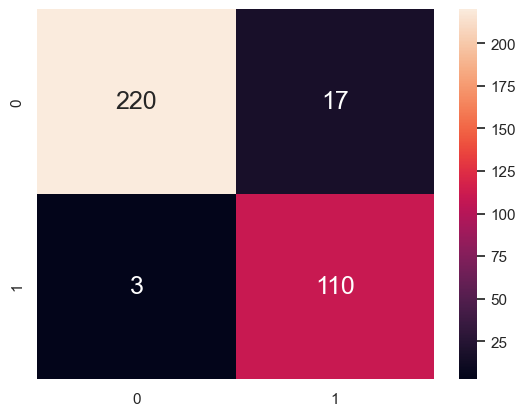

In [28]:
# Import the required metric from sklearn
from sklearn.metrics import confusion_matrix

# Predict the Response corresponding to Predictors
y_train_pred = dectree.predict(X_train)

# Plot the two-way Confusion Matrix
sb.heatmap(confusion_matrix(y_train, y_train_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18})

#### d)	
Which predictors are the most decisive in determining if the polymer is a thermoplastic or a thermosetting plastic?

In [30]:
pData.columns

Index(['Unnamed: 0', 'molecular_weight', 'polydispersity', 'crystallinity',
       'crosslink_density', 'processing_temp', 'cooling_rate', 'pressure',
       'glass_transition_temp', 'heat_deflection_temp', 'youngs_modulus',
       'tensile_strength', 'elongation_at_break', 'polymer_type'],
      dtype='object')

Train Set : (350, 1) (350, 1)
Test Set  : (150, 1) (150, 1)


[Text(0.5, 0.75, 'crystallinity <= 15.9\ngini = 0.427\nsamples = 350\nvalue = [242, 108]\nclass = Thermoplastic'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 108\nvalue = [0, 108]\nclass = Thermosetting'),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 242\nvalue = [242, 0]\nclass = Thermoplastic')]

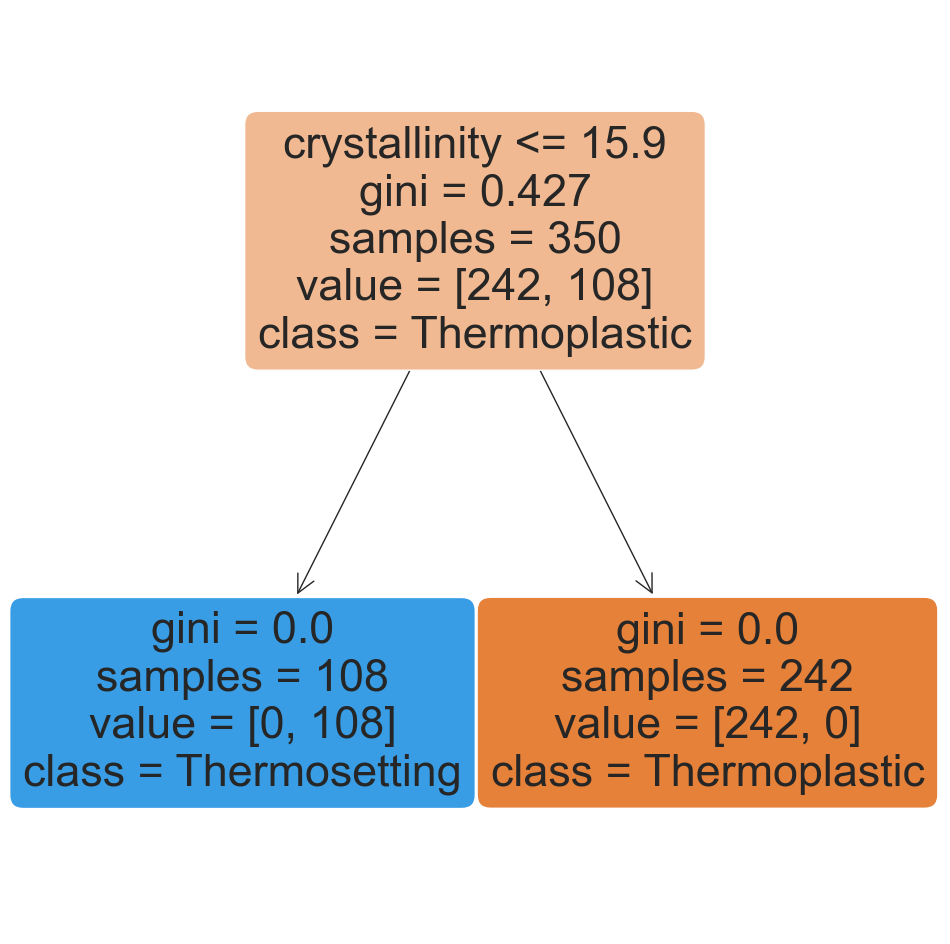

In [35]:
# Extract Response and Predictors
predictors = ['crystallinity']
y = pd.DataFrame(pData['polymer_type'])
X = pd.DataFrame(pData[predictors]) 

# Split the Dataset into random Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

# Check the sample sizes
print("Train Set :", X_train.shape, y_train.shape)
print("Test Set  :", X_test.shape, y_test.shape)

dectree.fit(X_train, y_train)

# Plot the trained Decision Tree
from sklearn.tree import plot_tree

f = plt.figure(figsize=(12,12))
plot_tree(dectree, filled=True, rounded=True, 
          feature_names=X_train.columns, 
          class_names=["Thermoplastic","Thermosetting"])

In [36]:
# Crystallinity and crosslink density both produce a decision tree of depth 1 only

# Q3: Clustering Problem - Metal Alloys

<b>Context:</b> An unknown hacker has broken into your company’s database and deleted the file containing the catalogue of metal alloys in the company inventory. Thankfully, the database itself, metal_data.csv is left intact. You are tasked to organise the list of metal alloys again according to their mechanical properties, hardness, tensile_strength, ductility, toughness, and density. Rewriting the catalogue will require you to discern the potential industrial applications suitable for each alloy recipe.

### a)	
Import the complete dataset “metal_data.csv” in Jupyter, as mData = pd.read_csv('metal_data.csv'). Set up a bivariate KMeans clustering routine using the fields ‘tensile_strength’ and ‘toughness’. What is the optimal number of clusters?

In [29]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics

In [30]:
mData = pd.read_csv('metal_data.csv')
mData.head()

,Unnamed: 0,hardness,tensile_strength,ductility,toughness,density
0,0,58.01,1928.57,11.98,294.06,8.49
1,1,56.61,1779.54,8.94,133.19,8.49
2,2,52.64,1836.78,12.27,194.99,8.37
3,3,57.94,1609.68,15.80,241.57,8.50
4,4,56.18,1675.43,8.93,156.52,8.41


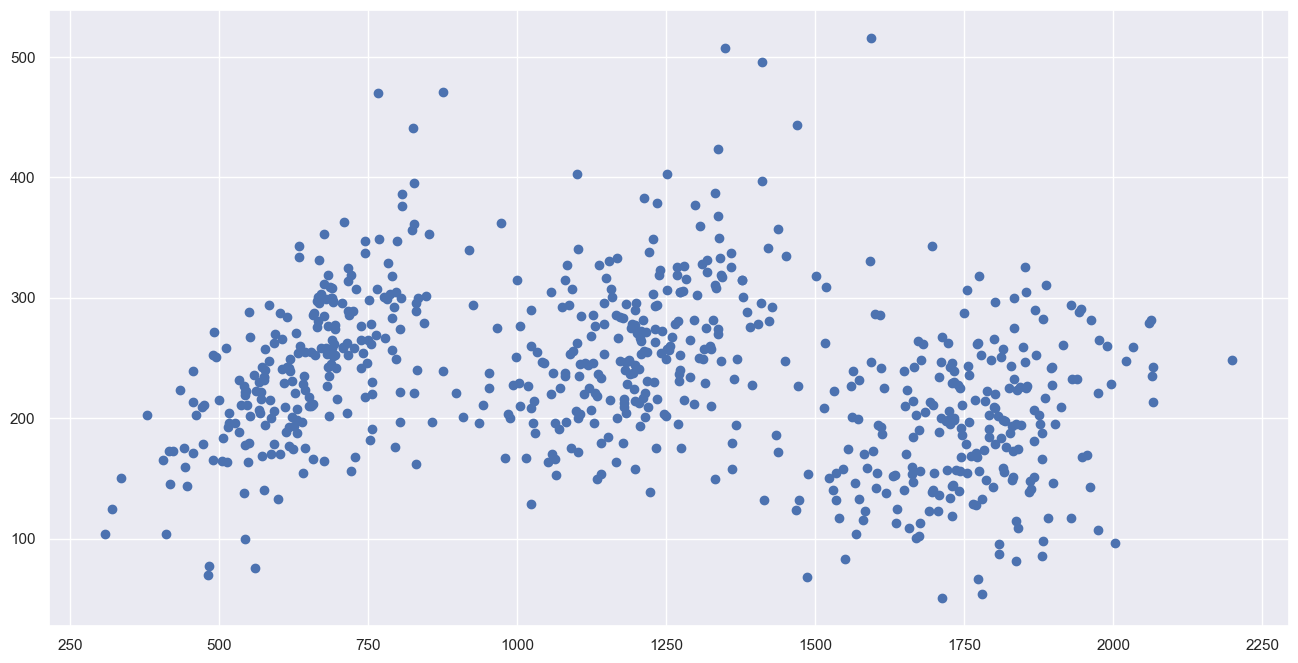

In [31]:
# Extract the Features from the Data
X = pd.DataFrame(mData[['tensile_strength','toughness']])
                           
# Plot the Raw Data on a 2D grid
f, axes = plt.subplots(1, 1, figsize=(16,8))
plt.scatter(x = "tensile_strength", y = "toughness", data = X)  

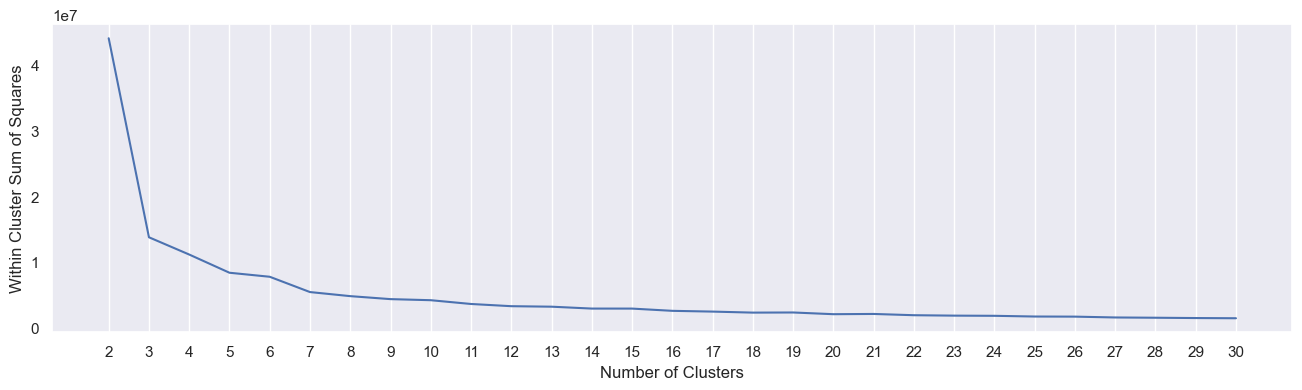

In [33]:
from sklearn.cluster import KMeans


# Vary the Number of Clusters
min_clust = 2
max_clust = 30

# Compute Within Cluster Sum of Squares
within_ss = []
for num_clust in range(min_clust, max_clust+1):
    kmeans = KMeans(n_clusters = num_clust)
    kmeans.fit(X)
    within_ss.append(kmeans.inertia_)

# Angle Plot : Within SS vs Number of Clusters
f, axes = plt.subplots(1, 1, figsize=(16,4))
plt.plot(range(min_clust, max_clust+1), within_ss)
plt.xlabel('Number of Clusters')
plt.ylabel('Within Cluster Sum of Squares')
plt.xticks(np.arange(min_clust, max_clust+1, 1.0))
plt.grid(which='major', axis='y')
plt.show()

### b)	
Interpret the clusters and visualize the cluster in the data

In [64]:
# Import KMeans from sklearn.cluster
from sklearn.cluster import KMeans

# Guess the Number of Clusters
num_clust = 3

# Create Clustering Model using KMeans
kmeans = KMeans(n_clusters = num_clust)

# Fit the Clustering Model on the Data
kmeans.fit(X)

C:\Users\andyp\anaconda3\envs\Vaspnest\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


KMeans(n_clusters=3)

In [65]:
# Print the Cluster Centers
print("Features", "\tTS", "\tToughness")
print()

for i, center in enumerate(kmeans.cluster_centers_):
    print("Cluster", i, end=":\t")
    for coord in center:
        print(round(coord, 2), end="\t")
    print()

Features 	TS 	Toughness

Cluster 0:	1757.42	196.45	
Cluster 1:	649.28	242.75	
Cluster 2:	1204.42	258.9	


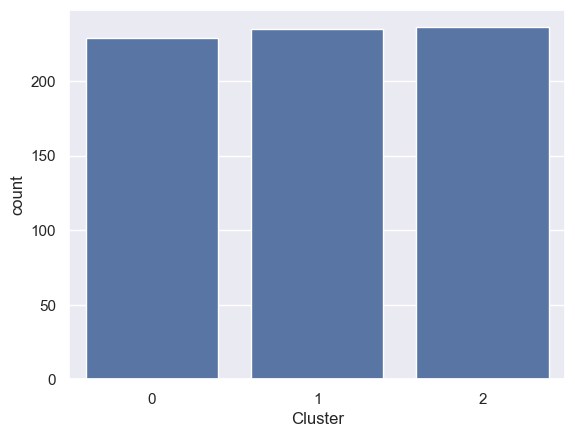

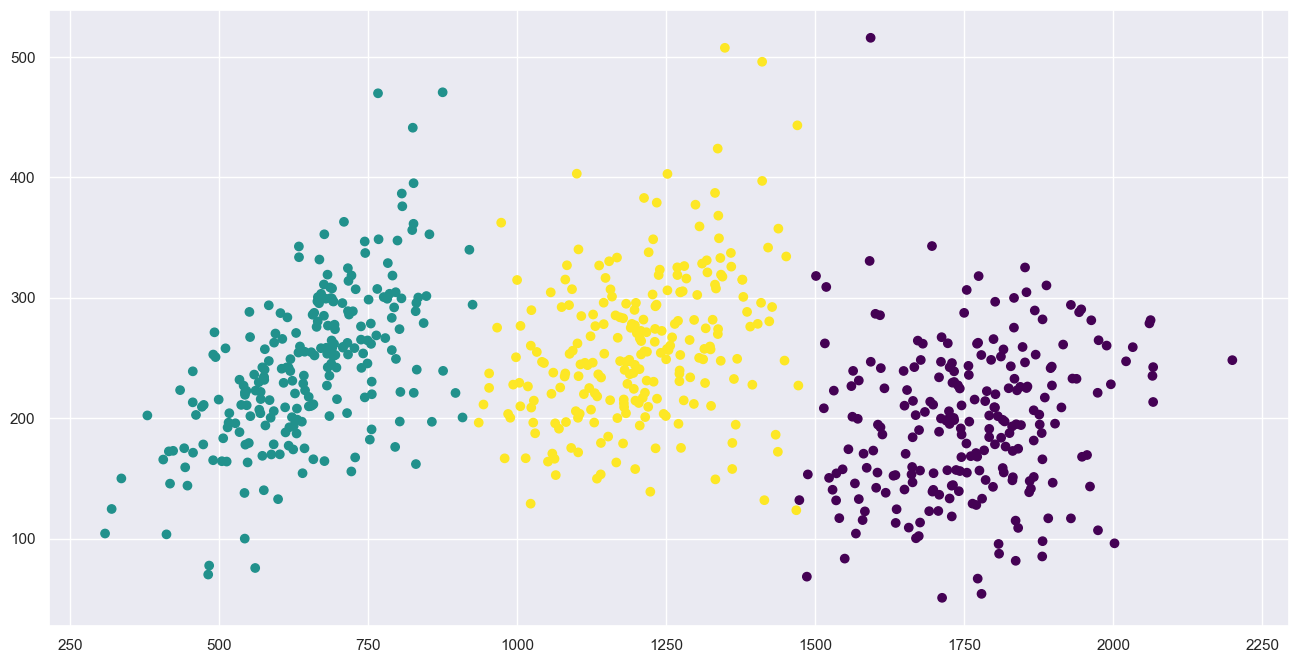

In [66]:
# Predict the Cluster Labels
labels = kmeans.predict(X)

# Append Labels to the Data
X_labeled = X.copy()
X_labeled["Cluster"] = pd.Categorical(labels)

# Summary of the Cluster Labels
sb.countplot(x=X_labeled["Cluster"])

# Visualize the Clusters in the Data
f, axes = plt.subplots(1, 1, figsize=(16,8))
plt.scatter(x = "tensile_strength", y = "toughness", c = "Cluster", cmap = 'viridis', data = X_labeled)

### c)	
Draw a countplot of Anomalies vs Normal Data, and visualize the anomalies on the 2D scatterplot.

In [67]:
# Import LocalOutlierFactor from sklearn.neighbors
from sklearn.neighbors import LocalOutlierFactor

# Set the Parameters for Neighborhood
num_neighbors = 50      # Number of Neighbors
cont_fraction = 0.01    # Fraction of Anomalies

# Create Anomaly Detection Model using LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors = num_neighbors, contamination = cont_fraction)

# Fit the Model on the Data and Predict Anomalies
lof.fit(X)

LocalOutlierFactor(contamination=0.01, n_neighbors=50)

<Axes: xlabel='Anomaly', ylabel='count'>

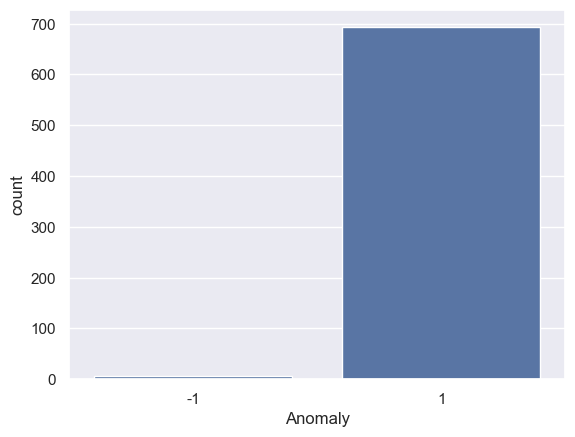

In [68]:
# Predict the Anomalies
labels = lof.fit_predict(X)

# Append Labels to the Data
X_labeled = X.copy()
X_labeled["Anomaly"] = pd.Categorical(labels)

# Summary of the Anomaly Labels
sb.countplot(x=X_labeled["Anomaly"])

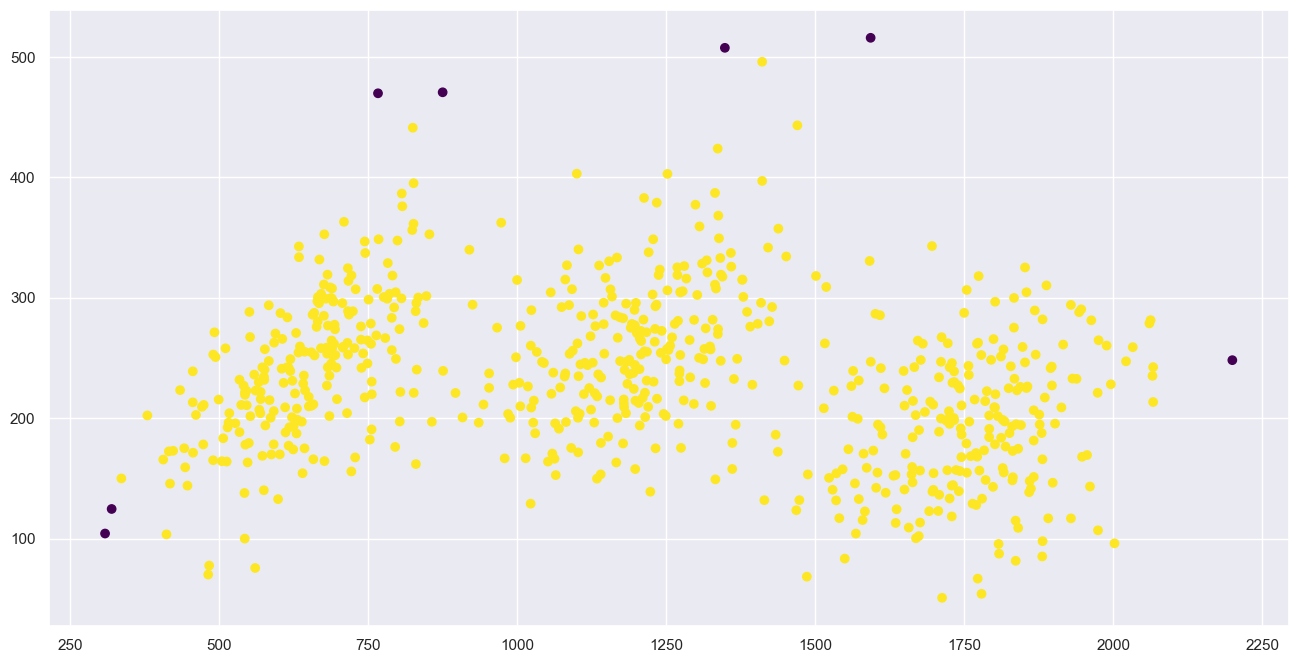

In [69]:
# Visualize the Anomalies in the Data
f, axes = plt.subplots(1, 1, figsize=(16,8))
plt.scatter(x = "tensile_strength", y = "toughness", c = "Anomaly", cmap = 'viridis', data = X_labeled)

### d)	
Using KMeans++, set up a multivariate clustering routine using all fields (hardness, tensile_strength, ductility, toughness, and density) in the dataset. Plot the boxplots of all the features with reference to the clusters, as well as the mean values of the features in a bar chart, grouped by cluster. Using your interpretation, what is the meaning of each cluster?

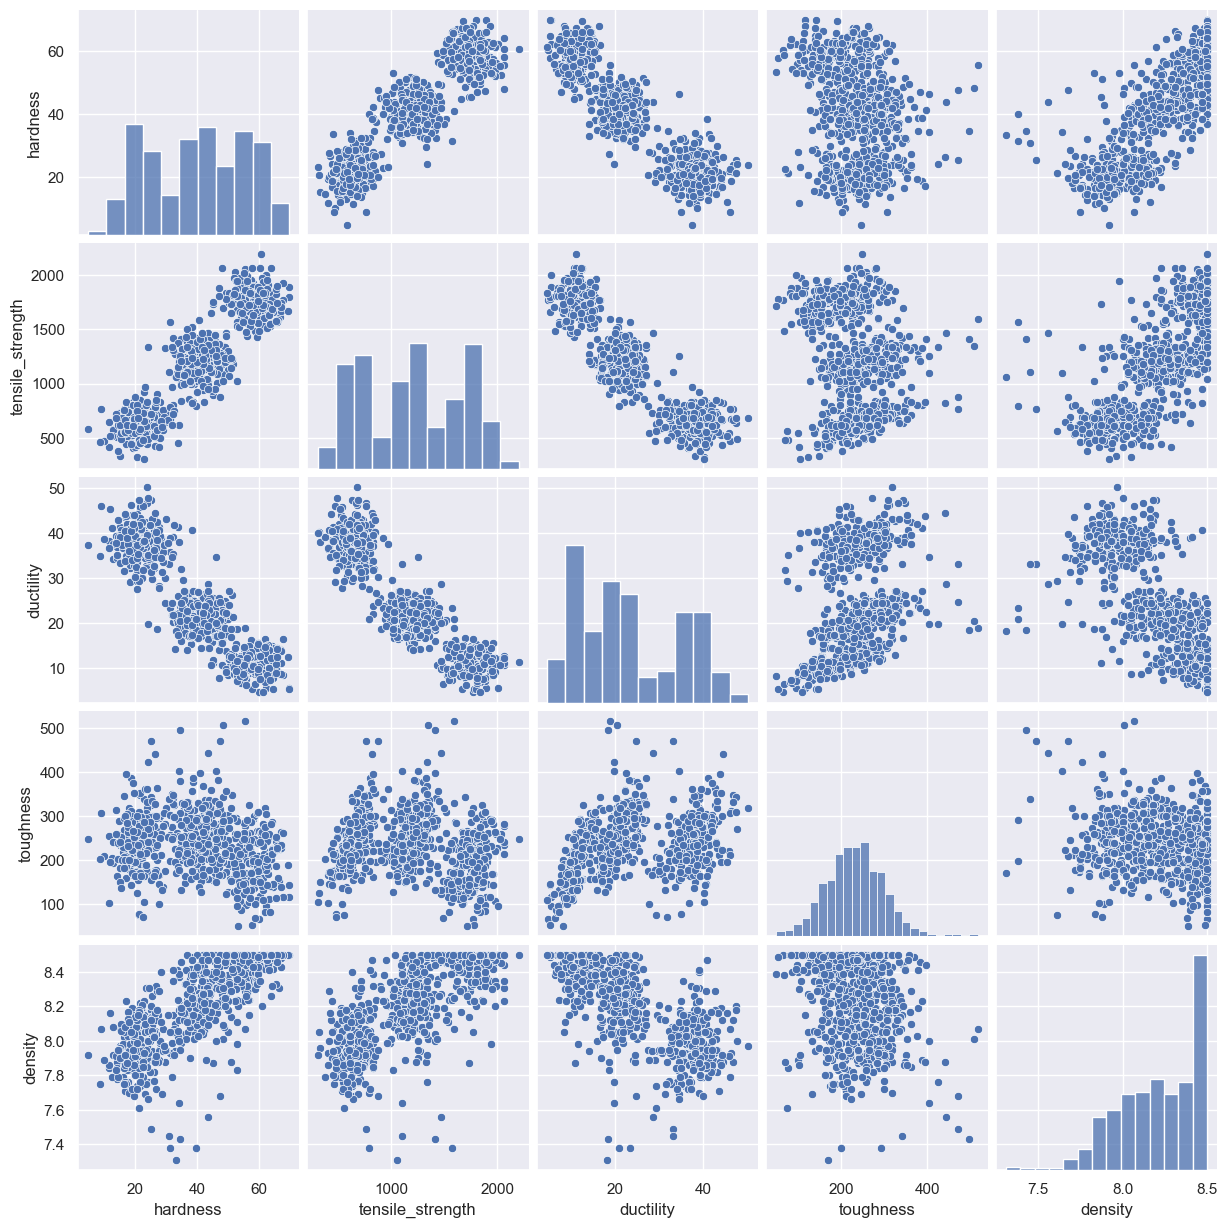

In [70]:
# Extract the Features from the Data
X = pd.DataFrame(mData[['hardness','tensile_strength','ductility','toughness','density']]) 

# Plot the Raw Data on 2D grids
sb.pairplot(X)

C:\Users\andyp\anaconda3\envs\Vaspnest\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\andyp\anaconda3\envs\Vaspnest\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\andyp\anaconda3\envs\Vaspnest\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\andyp\anaconda3\envs\Vaspnest\lib\site-packages\sklearn\cluster\_kmeans.py:1446: User

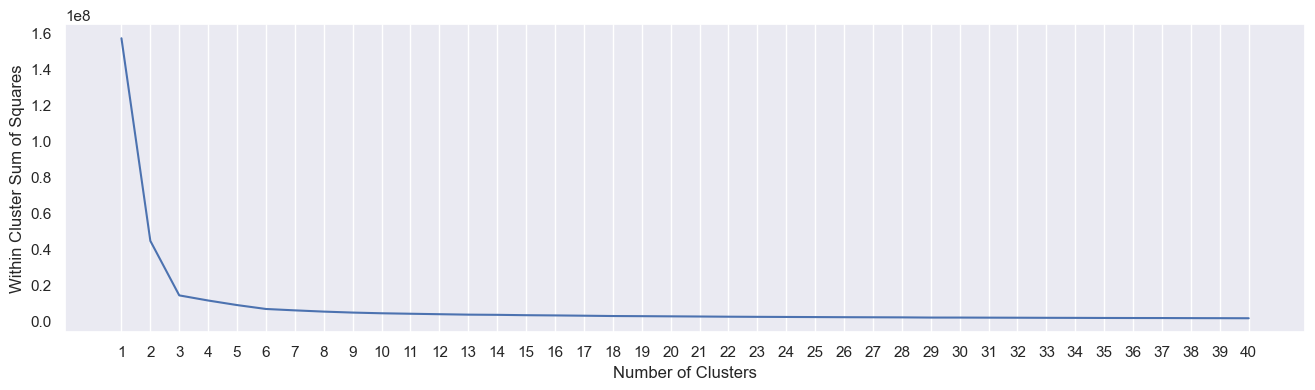

In [71]:
# Vary the Number of Clusters
min_clust = 1
max_clust = 40

# Compute Within Cluster Sum of Squares
within_ss = []
for num_clust in range(min_clust, max_clust+1):
    kmeans = KMeans(n_clusters = num_clust, init = 'k-means++', n_init = 5)
    kmeans.fit(X)
    within_ss.append(kmeans.inertia_)

# Angle Plot : Within SS vs Number of Clusters
f, axes = plt.subplots(1, 1, figsize=(16,4))
plt.plot(range(min_clust, max_clust+1), within_ss)
plt.xlabel('Number of Clusters')
plt.ylabel('Within Cluster Sum of Squares')
plt.xticks(np.arange(min_clust, max_clust+1, 1.0))
plt.grid(which='major', axis='y')
plt.show()

In [72]:
# Import essential models from sklearn
from sklearn.cluster import KMeans

# Set "optimal" Clustering Parameters
num_clust = 3
init_algo = 'k-means++'

# Create Clustering Model using KMeans
kmeans = KMeans(n_clusters = num_clust,         
               init = init_algo,
               n_init = 20)                 

# Fit the Clustering Model on the Data
kmeans.fit(X)

C:\Users\andyp\anaconda3\envs\Vaspnest\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


KMeans(n_clusters=3, n_init=20)

Features 	Hard 	TS 	Duct 	Tough 	Dense

Cluster 0:	57.7	1756.16	11.23	196.13	8.42	
Cluster 1:	41.34	1202.12	21.14	259.62	8.23	
Cluster 2:	22.03	648.11	37.36	242.53	7.98	

Within Cluster Sum of Squares : 13784434.934691247



<Axes: xlabel='Cluster', ylabel='count'>

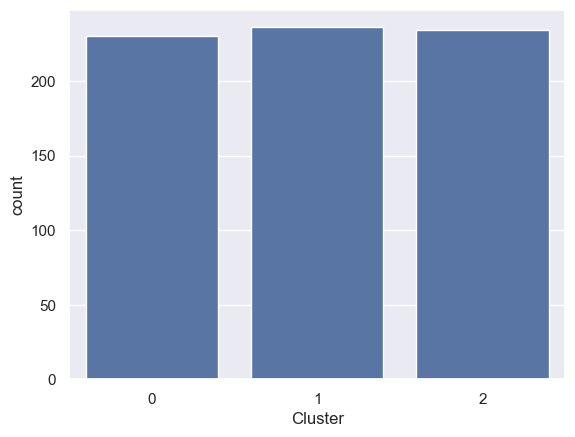

In [73]:
# Print the Cluster Centers
print("Features", "\tHard", "\tTS", "\tDuct", "\tTough", "\tDense")
print()

for i, center in enumerate(kmeans.cluster_centers_):
    print("Cluster", i, end=":\t")
    for coord in center:
        print(round(coord, 2), end="\t")
    print()
print()

# Print the Within Cluster Sum of Squares
print("Within Cluster Sum of Squares :", kmeans.inertia_)
print()

# Predict the Cluster Labels
labels = kmeans.predict(X)

# Append Labels to the Data
X_labeled = X.copy()
X_labeled["Cluster"] = pd.Categorical(labels)

# Summary of the Cluster Labels
sb.countplot(x=X_labeled["Cluster"])

<Axes: xlabel='density', ylabel='Cluster'>

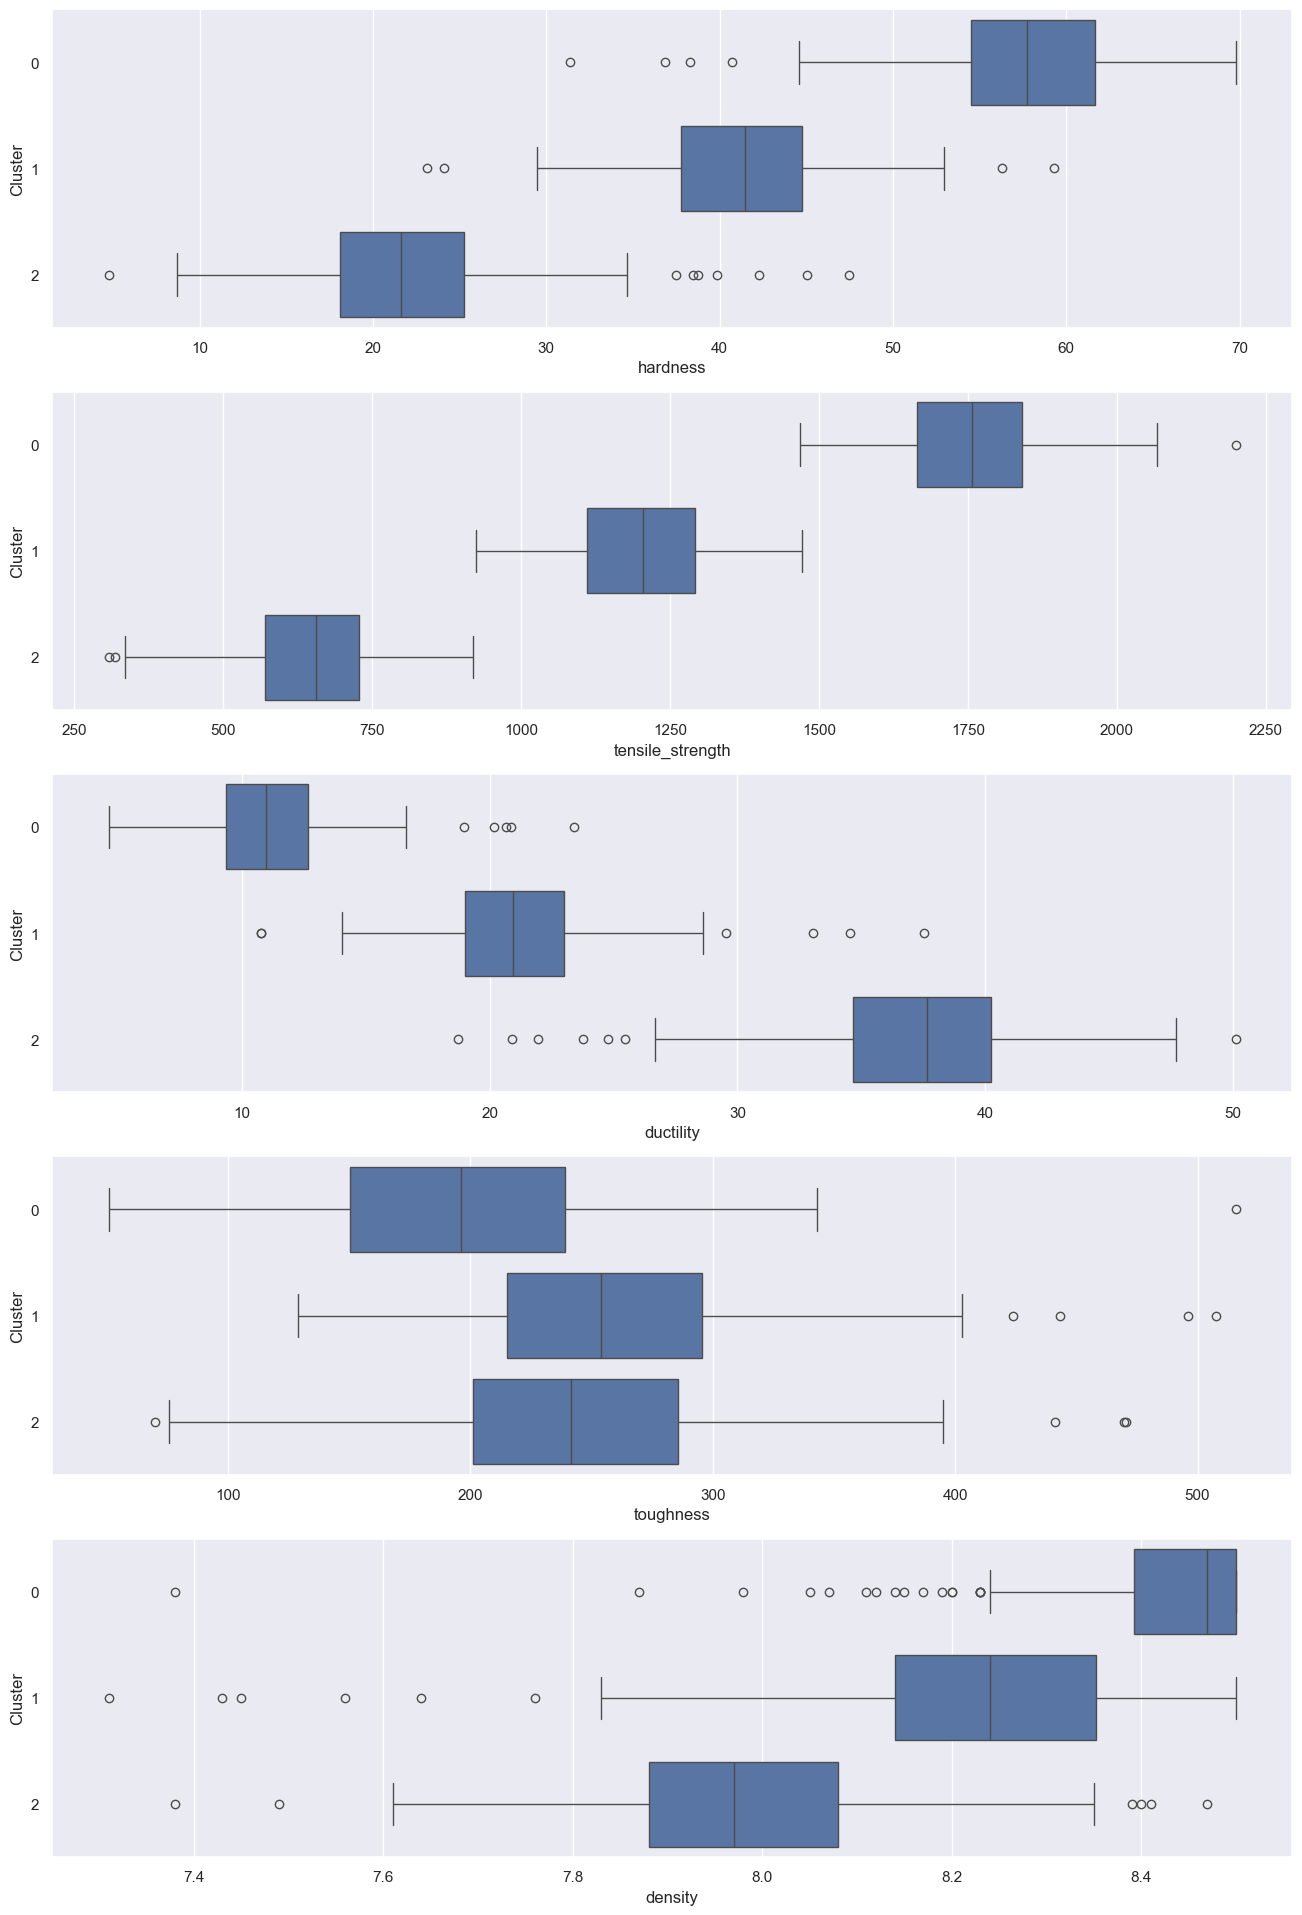

In [75]:
# Boxplots for all Features against the Clusters
# 'hardness','tensile_strength','ductility','toughness','density'
f, axes = plt.subplots(5, 1, figsize=(16,24))
sb.boxplot(x = 'hardness', y = 'Cluster', data = X_labeled, ax = axes[0])
sb.boxplot(x = 'tensile_strength', y = 'Cluster', data = X_labeled, ax = axes[1])
sb.boxplot(x = 'ductility', y = 'Cluster', data = X_labeled, ax = axes[2])
sb.boxplot(x = 'toughness', y = 'Cluster', data = X_labeled, ax = axes[3])
sb.boxplot(x = 'density', y = 'Cluster', data = X_labeled, ax = axes[4])

C:\Users\andyp\AppData\Local\Temp\ipykernel_25040\3914299649.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_data = pd.DataFrame(X_labeled.groupby(by = "Cluster").mean())


<Axes: xlabel='Cluster'>

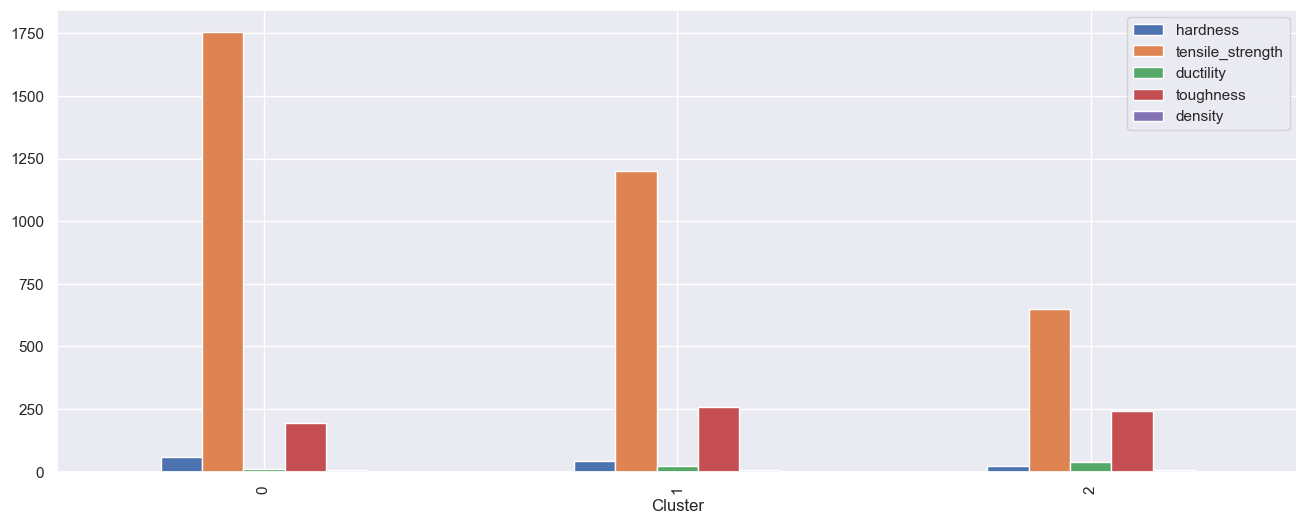

In [76]:
# Average Behaviour of each Cluster
cluster_data = pd.DataFrame(X_labeled.groupby(by = "Cluster").mean())
cluster_data.plot.bar(figsize = (16,6))